In [66]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler
from sklearn.metrics import precision_score, recall_score, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import GaussianNB

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv("loan_approval_data.csv")
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


## Handeling missing values

In [3]:
data = df.dropna(subset=["Loan_Approved"]).reset_index(drop=True)  # removing every row where target in Null

In [7]:
num_cols = data.select_dtypes(include="number").columns
cat_cols = data.select_dtypes(include="object").columns

num_imputer = SimpleImputer(strategy="mean")
data[num_cols] = num_imputer.fit_transform(data[num_cols])  # Fill "NaN" value with "mean" in numeric colums

cat_imputer = SimpleImputer(strategy="most_frequent")
data[cat_cols] = cat_imputer.fit_transform(data[cat_cols])

data = data.drop("Applicant_ID",axis=1)
data.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## EDA

([<matplotlib.patches.Wedge at 0x19e5678c980>,
 [Text(-0.6077203342081817, 0.91688385054482, 'No'),
  Text(0.6077206329668295, -0.9168836525243518, 'Yes')],
 [Text(-0.33148381865900817, 0.5001184639335382, '68.6%'),
  Text(0.3314839816182706, -0.5001183559223736, '31.4%')])

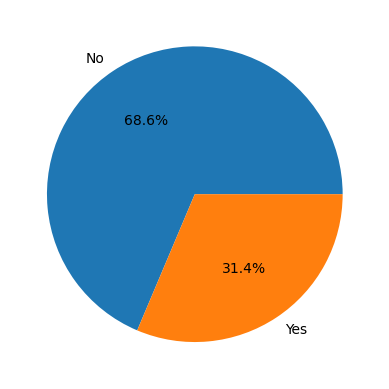

In [11]:
# Class dristribution

classes_count = data["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=classes_count.index, autopct ="%1.1f%%")

[Text(0, 0, '240'),
 Text(0, 0, '192'),
 Text(0, 0, '180'),
 Text(0, 0, '169'),
 Text(0, 0, '169')]

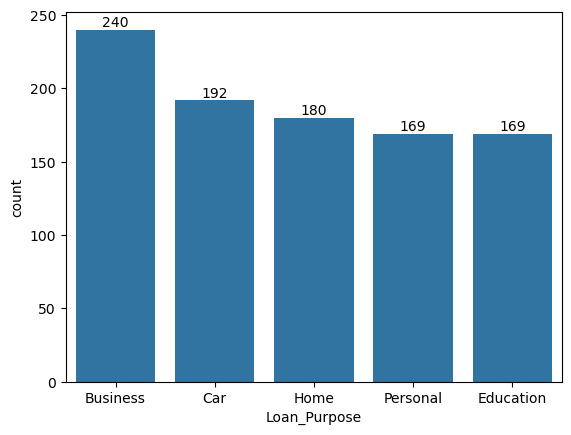

In [14]:
# Purpose

purpose_count = data["Loan_Purpose"].value_counts()
pc = sns.barplot(purpose_count)
pc.bar_label(pc.containers[0])

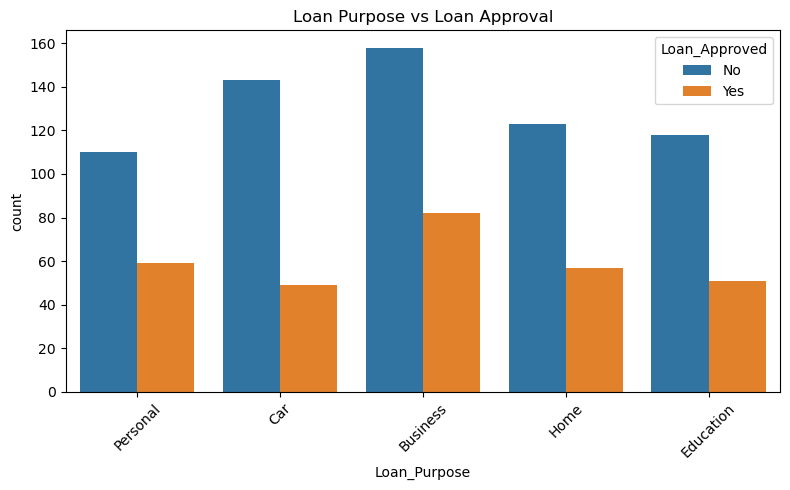

In [22]:
# Purvose vs Approved

plt.figure(figsize=(8,5))

sns.countplot(data=data, x="Loan_Purpose", hue="Loan_Approved")
plt.title("Loan Purpose vs Loan Approval")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

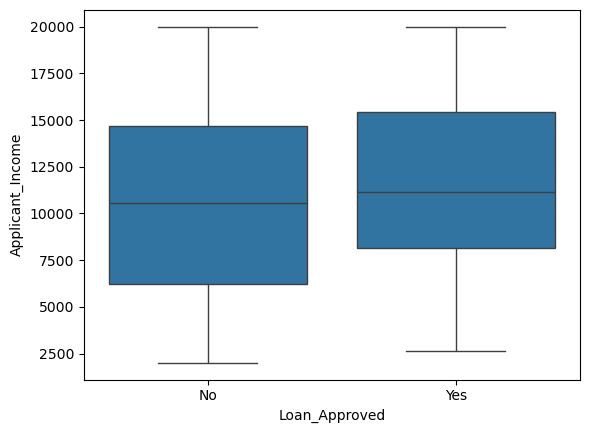

In [23]:
# income vs loan approved

sns.boxplot(data=data, x="Loan_Approved",y="Applicant_Income")

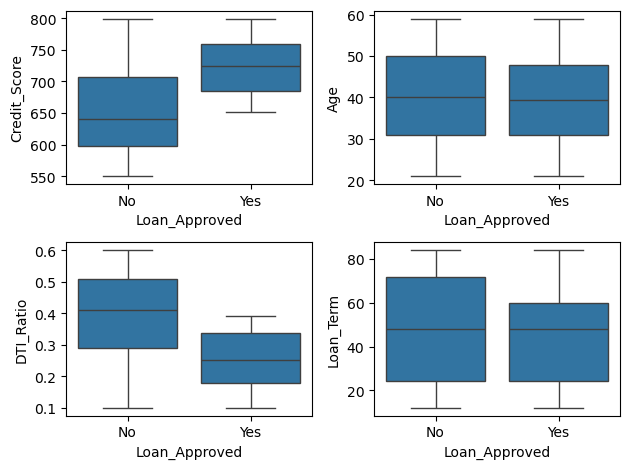

In [29]:
fig, axes = plt.subplots(2,2)

sns.boxplot(ax=axes[0,0], data=data, x="Loan_Approved",y="Credit_Score")
sns.boxplot(ax=axes[0,1], data=data, x="Loan_Approved",y="Age")
sns.boxplot(ax=axes[1,0], data=data, x="Loan_Approved",y="DTI_Ratio")
sns.boxplot(ax=axes[1,1], data=data, x="Loan_Approved",y="Loan_Term")
plt.tight_layout()

# Encoding

In [39]:
lbe = LabelEncoder()
data["Education_Level"] = lbe.fit_transform(data["Education_Level"])
data["Loan_Approved"] = lbe.fit_transform(data["Loan_Approved"])
data["Gender"] = lbe.fit_transform(data["Gender"])

cols = ["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")
encoded = ohe.fit_transform(data[cols])
encoded_df = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(cols), index=data.index)
data = pd.concat([data.drop(columns=cols), encoded_df], axis=1)

In [40]:
data.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,Gender,Loan_Approved,Employment_Status_Salaried,Employment_Status_Self-employed,Employment_Status_Unemployed,Marital_Status_Single,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,1,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,0,1,0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,0,0,1,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,0,1,1,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# Correlation Heatmap

In [44]:
num_cols = data.select_dtypes(include="number")
corr_matrix = num_cols.corr()
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.476911
Applicant_Income                   0.125010
Employer_Category_MNC              0.073448
Marital_Status_Single              0.037586
Loan_Purpose_Personal              0.035519
Collateral_Value                   0.027350
Property_Area_Urban                0.025731
Coapplicant_Income                 0.009127
Loan_Purpose_Home                  0.003108
Employer_Category_Private          0.000707
Employment_Status_Self-employed   -0.001572
Loan_Purpose_Education            -0.011940
Property_Area_Semiurban           -0.014259
Dependents                        -0.016199
Savings                           -0.016857
Age                               -0.027393
Employer_Category_Unemployed      -0.028736
Existing_Loans                    -0.035384
Employer_Category_Government      -0.039135
Employment_Status_Salaried        -0.046912
Employment_Status_Unemployed      -0.047256
Gender                          

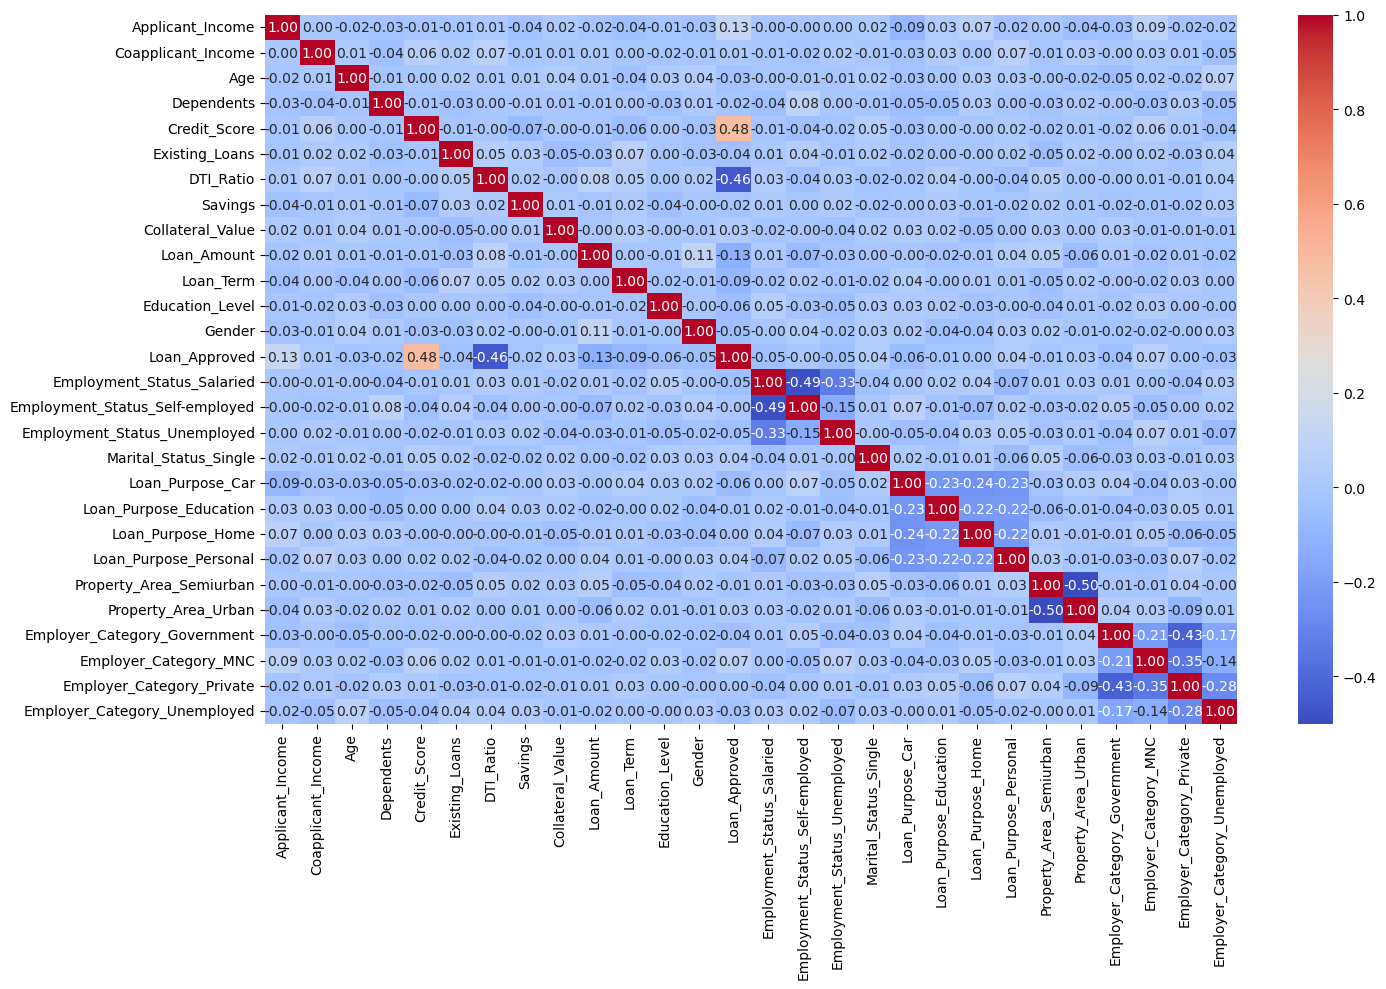

In [47]:
plt.figure(figsize=[15,10])

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt = ".2f",
    cmap="coolwarm"
)
plt.tight_layout()

## Train_Test_Split and Feature scaling

In [49]:
X = data.drop("Loan_Approved",axis=1)
y = data["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic reg

In [52]:
lr = LogisticRegression(max_iter=100000)
lr.fit(X_train_scaled,y_train)

y_pred = lr.predict(X_test_scaled)

In [55]:
print("precision:",precision_score(y_test,y_pred))  # False +ve     (mst imp for this problem)
print("recall:",recall_score(y_test,y_pred))   # False -ve
print("accuracy:",accuracy_score(y_test,y_pred))

precision: 0.8727272727272727
recall: 0.7868852459016393
accuracy: 0.8947368421052632


## KNN

In [65]:
pipe = Pipeline([                  # scale => train data, normalize => validatio data
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])
param_grid = {"knn__n_neighbors":[3,5,7,9,11]}

classifierCV = GridSearchCV(
    pipe,
    param_grid,
    scoring = "precision",
    cv=5
)

classifierCV.fit(X_train,y_train)

y_pred = classifierCV.predict(X_test)

print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))   
print("accuracy:",accuracy_score(y_test,y_pred))

print(classifierCV.best_params_,"\n")

print("Optimizing for reducing bad customers => Precision")

precision: 0.78125
recall: 0.4098360655737705
accuracy: 0.7736842105263158
{'knn__n_neighbors': 11} 

Optimizing for reducing bad customers => Precision


## Naive Bayes

In [68]:
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

y_pred = gnb.predict(X_test_scaled)

print("precision:",precision_score(y_test,y_pred))
print("recall:",recall_score(y_test,y_pred))   
print("accuracy:",accuracy_score(y_test,y_pred))

precision: 0.8979591836734694
recall: 0.7213114754098361
accuracy: 0.8842105263157894
